In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.datasets import Caltech101
from torchvision import transforms
from torch.utils.data import random_split, DataLoader

In [3]:
from torchvision.datasets import Caltech101
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # بعض صور Caltech101 grayscale
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = Caltech101(root='./data', transform=transform, download=True)

100%|██████████| 137M/137M [00:02<00:00, 60.6MB/s] 


In [4]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

In [5]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet34(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 194MB/s] 


In [6]:
model = models.resnet34(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, 102)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=0.001
)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%")

Epoch 1/10 | Loss: 1.0963 | Val Acc: 84.62%
Epoch 2/10 | Loss: 0.3068 | Val Acc: 86.58%
Epoch 3/10 | Loss: 0.1551 | Val Acc: 91.82%
Epoch 4/10 | Loss: 0.0953 | Val Acc: 91.76%
Epoch 5/10 | Loss: 0.0851 | Val Acc: 88.59%
Epoch 6/10 | Loss: 0.0511 | Val Acc: 93.61%
Epoch 7/10 | Loss: 0.0479 | Val Acc: 90.96%
Epoch 8/10 | Loss: 0.0550 | Val Acc: 92.63%
Epoch 9/10 | Loss: 0.0532 | Val Acc: 90.44%
Epoch 10/10 | Loss: 0.0571 | Val Acc: 92.05%


In [18]:
torch.save(model.state_dict(), 'resnet34_caltech101.pth')

# phase 2

In [9]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

min_val = (0 - mean) / std
max_val = (1 - mean) / std

def fgsm_attack(model, image, label, epsilon):
    image = image.clone().detach().to(device)
    image.requires_grad = True
    
    output = model(image)
    loss = criterion(output, label)
    
    model.zero_grad()
    loss.backward()
    
    data_grad = image.grad.data
    
    perturbed_image = image + epsilon * data_grad.sign()
    perturbed_image = torch.clamp(perturbed_image, min_val, max_val)
    
    return perturbed_image.detach()

In [10]:
# ناخد batch واحد بس من val_loader
data_iter = iter(val_loader)
images, labels = next(data_iter)
images, labels = images.to(device), labels.to(device)

# ناخد صورة واحدة بس (أول واحدة في الـ batch) عشان التجربة
image = images[0:1]
label = labels[0:1]

# تنبؤ الموديل قبل الهجوم
model.eval()
output = model(image)
_, pred_before = torch.max(output, 1)
print(f"Prediction BEFORE attack: {pred_before.item()} | True label: {label.item()}")

# نطبق الهجوم
epsilon = 0.03
perturbed_image = fgsm_attack(model, image, label, epsilon)

# تنبؤ الموديل بعد الهجوم
output_after = model(perturbed_image)
_, pred_after = torch.max(output_after, 1)
print(f"Prediction AFTER attack:  {pred_after.item()} | True label: {label.item()}")

Prediction BEFORE attack: 20 | True label: 20
Prediction AFTER attack:  99 | True label: 20


In [11]:
epsilons = [0, 0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 0.2]

print(f"True label: {label.item()}\n")

for eps in epsilons:
    perturbed_image = fgsm_attack(model, image, label, eps)
    output = model(perturbed_image)
    _, pred = torch.max(output, 1)
    
    status = "Correct" if pred.item() == label.item() else "WRONG"
    print(f"Epsilon = {eps:<6} | Prediction: {pred.item():<4} | {status}")

True label: 20

Epsilon = 0      | Prediction: 20   | Correct
Epsilon = 0.001  | Prediction: 99   | WRONG
Epsilon = 0.005  | Prediction: 99   | WRONG
Epsilon = 0.01   | Prediction: 99   | WRONG
Epsilon = 0.03   | Prediction: 99   | WRONG
Epsilon = 0.05   | Prediction: 99   | WRONG
Epsilon = 0.1    | Prediction: 83   | WRONG
Epsilon = 0.2    | Prediction: 74   | WRONG


In [12]:
def test_attack_accuracy(model, loader, epsilon, max_batches=None):
    model.eval()
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(loader):
        if max_batches and i >= max_batches:
            break
        
        images, labels = images.to(device), labels.to(device)
        
        perturbed_images = fgsm_attack(model, images, labels, epsilon)
        
        outputs = model(perturbed_images)
        _, preds = torch.max(outputs, 1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    accuracy = 100 * correct / total
    return accuracy


epsilons = [0, 0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 0.2]

print("Accuracy under FGSM attack (across validation set):\n")
for eps in epsilons:
    acc = test_attack_accuracy(model, val_loader, eps, max_batches=10)  # 10 batches الأول للسرعة
    print(f"Epsilon = {eps:<6} | Accuracy: {acc:.2f}%")

Accuracy under FGSM attack (across validation set):

Epsilon = 0      | Accuracy: 89.69%
Epsilon = 0.001  | Accuracy: 64.38%
Epsilon = 0.005  | Accuracy: 47.50%
Epsilon = 0.01   | Accuracy: 47.81%
Epsilon = 0.03   | Accuracy: 50.00%
Epsilon = 0.05   | Accuracy: 40.31%
Epsilon = 0.1    | Accuracy: 5.94%
Epsilon = 0.2    | Accuracy: 1.25%


In [13]:
epsilons = [0, 0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 0.2]

print("Accuracy under FGSM attack (across FULL validation set):\n")
for eps in epsilons:
    acc = test_attack_accuracy(model, val_loader, eps, max_batches=None)  # None = كل الـ val_loader
    print(f"Epsilon = {eps:<6} | Accuracy: {acc:.2f}%")

Accuracy under FGSM attack (across FULL validation set):

Epsilon = 0      | Accuracy: 92.05%
Epsilon = 0.001  | Accuracy: 62.90%
Epsilon = 0.005  | Accuracy: 43.95%
Epsilon = 0.01   | Accuracy: 45.28%
Epsilon = 0.03   | Accuracy: 49.31%
Epsilon = 0.05   | Accuracy: 41.19%
Epsilon = 0.1    | Accuracy: 7.09%
Epsilon = 0.2    | Accuracy: 0.75%


# phase 3

In [14]:
def generate_saliency_map(model, image, label):
    model.eval()
    image = image.clone().detach().to(device)
    image.requires_grad = True
    
    output = model(image)
    loss = criterion(output, label)
    
    model.zero_grad()
    loss.backward()
    
    # ناخد الـ gradient بتاع الصورة (زي fgsm بالظبط)
    data_grad = image.grad.data
    
    # ناخد القيمة المطلقة (مش الاتجاه، بس "قد ايه مهم")
    saliency = data_grad.abs()
    
    # ناخد أقصى قيمة عبر الـ 3 channels (RGB) لكل pixel
    saliency, _ = torch.max(saliency, dim=1)  # dim=1 هو الـ channels axis
    
    return saliency.squeeze().cpu().numpy()

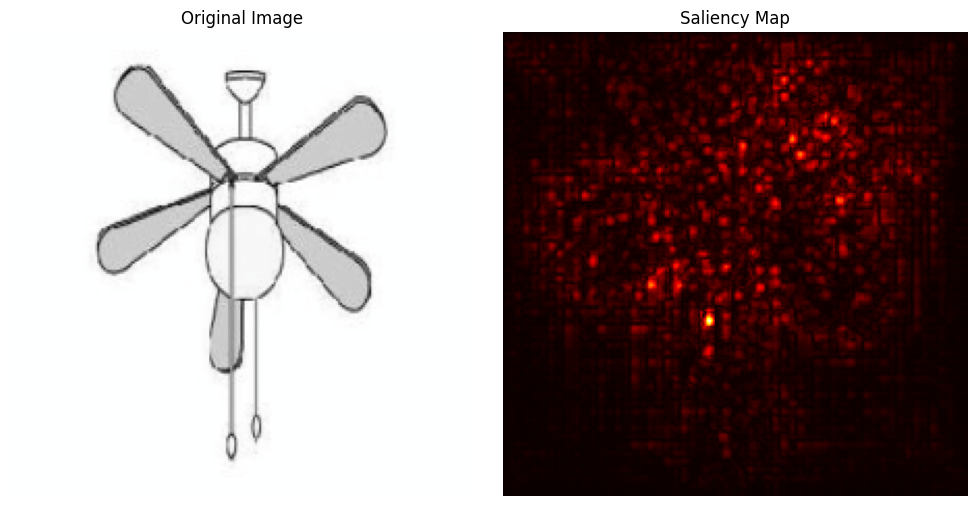

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# نستخدم نفس الصورة اللي جربنا بيها الهجوم قبل كده
saliency_map = generate_saliency_map(model, image, label)

# عشان نعرض الصورة الأصلية، لازم نـ"denormalize" الأول (نرجعها لقيم 0-1)
def denormalize(img_tensor):
    mean_np = np.array([0.485, 0.456, 0.406])
    std_np = np.array([0.229, 0.224, 0.225])
    img = img_tensor.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    img = img * std_np + mean_np
    img = np.clip(img, 0, 1)
    return img

original_img = denormalize(image)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_img)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(saliency_map, cmap='hot')
axes[1].set_title("Saliency Map")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [25]:
def generate_gradcam(model, image, label):
    model.eval()
    image = image.clone().detach().to(device)
    
    output = model(image)
    
    model.zero_grad()
    loss = criterion(output, label)
    loss.backward()
    
    # activations شكلها: [batch, channels, H, W] -- زي [1, 512, 7, 7] في ResNet-34 layer4
    # gradients نفس الشكل
    
    # الخطوة 1: متوسط كل الـ gradients لكل channel (يدّينا "وزن" لكل channel)
    weights = gradients.mean(dim=(2, 3), keepdim=True)  # shape: [1, 512, 1, 1]
    
    # الخطوة 2: weighted sum بين الـ weights والـ activations
    cam = (weights * activations).sum(dim=1, keepdim=True)  # shape: [1, 1, 7, 7]
    
    # الخطوة 3: ReLU (نشيل القيم السالبة)
    cam = torch.relu(cam)
    
    # الخطوة 4: نكبّر الـ heatmap لحجم الصورة الأصلية (224x224)
    cam = torch.nn.functional.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
    
    # نطبّع القيم بين 0 و 1 عشان نرسمها
    cam = cam.squeeze().cpu().detach().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    
    return cam

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


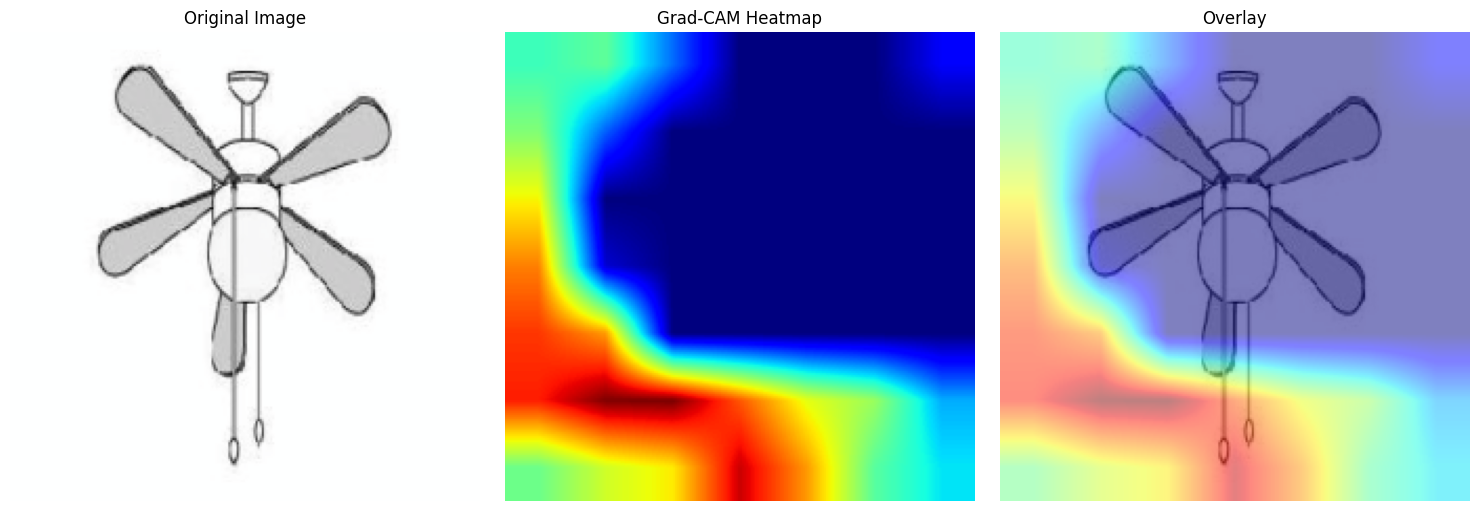

In [26]:
gradcam_map = generate_gradcam(model, image, label)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_img)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(gradcam_map, cmap='jet')
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis('off')

axes[2].imshow(original_img)
axes[2].imshow(gradcam_map, cmap='jet', alpha=0.5)  # alpha = شفافية
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# phase 4

In [ ]:
def visualize_noise(noise_tensor):
    noise = noise_tensor.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    # نطبع القيم عشان تبان بوضوح (مش القيم الحقيقية، بس للعرض البصري)
    noise_display = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)
    return noise_display

In [ ]:
def forensic_analysis(model, image, label, epsilon, class_names=None):
    model.eval()
    image = image.to(device)
    label = label.to(device)
    
    # 1. التنبؤ الأصلي (clean)
    output_clean = model(image)
    _, pred_clean = torch.max(output_clean, 1)
    
    # 2. XAI على الصورة النضيفة
    saliency_clean = generate_saliency_map(model, image, label)
    gradcam_clean = generate_gradcam(model, image, label)
    
    # 3. الهجوم
    perturbed_image = fgsm_attack(model, image, label, epsilon)
    output_attacked = model(perturbed_image)
    _, pred_attacked = torch.max(output_attacked, 1)
    
    # 4. الـ noise
    noise = perturbed_image - image
    noise_display = visualize_noise(noise)
    
    # 5. XAI على الصورة المهاجَمة (بنستخدم pred_attacked مش label الصح، عشان نفهم ليه الموديل قال كده)
    saliency_attacked = generate_saliency_map(model, perturbed_image, pred_attacked)
    gradcam_attacked = generate_gradcam(model, perturbed_image, pred_attacked)
    
    # الرسم: 6 صور في صف واحد
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    axes[0,0].imshow(denormalize(image)); axes[0,0].set_title(f"Clean | Pred: {pred_clean.item()}"); axes[0,0].axis('off')
    axes[0,1].imshow(saliency_clean, cmap='hot'); axes[0,1].set_title("Saliency (Clean)"); axes[0,1].axis('off')
    axes[0,2].imshow(gradcam_clean, cmap='jet'); axes[0,2].set_title("Grad-CAM (Clean)"); axes[0,2].axis('off')
    axes[0,3].axis('off')  # فاضي
    
    axes[1,0].imshow(denormalize(perturbed_image)); axes[1,0].set_title(f"Attacked | Pred: {pred_attacked.item()}"); axes[1,0].axis('off')
    axes[1,1].imshow(noise_display); axes[1,1].set_title("Adversarial Noise"); axes[1,1].axis('off')
    axes[1,2].imshow(saliency_attacked, cmap='hot'); axes[1,2].set_title("Saliency (Attacked)"); axes[1,2].axis('off')
    axes[1,3].imshow(gradcam_attacked, cmap='jet'); axes[1,3].set_title("Grad-CAM (Attacked)"); axes[1,3].axis('off')
    
    plt.suptitle(f"Forensic Analysis | True Label: {label.item()} | Epsilon: {epsilon}")
    plt.tight_layout()
    plt.show()
    
    return {
        'pred_clean': pred_clean.item(),
        'pred_attacked': pred_attacked.item(),
        'true_label': label.item()
    }

In [ ]:
results = forensic_analysis(model, image, label, epsilon=0.03)
print(results)

"الفشل بيحصل مش لأن فيه noise كتير، لكن لأن الـ noise ده محسوب بدقة (باستخدام gradient الموديل نفسه) عشان يدفع قرار الموديل في اتجاه معين. الـ Grad-CAM بيوريكي إن التشويش الصغير ده قدر 'يزحلق' انتباه الموديل لمنطقة مختلفة شوية عن المنطقة الأصلية، وده كافي يخليه ياخد قرار مختلف تمامًا، رغم إن العين المجردة مش قادرة تلاحظ أي فرق في الصورة."

In [ ]:
# ناخد batch وناخد منه كذا صورة مختلفة
data_iter = iter(val_loader)
images_batch, labels_batch = next(data_iter)
images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)

# نختار 3 صور مختلفة من الـ batch (مثلاً index 0, 5, 10)
selected_indices = [0, 5, 10]

for idx in selected_indices:
    img = images_batch[idx:idx+1]
    lbl = labels_batch[idx:idx+1]
    
    # نتأكد الأول إن الموديل بيصنفها صح أصلاً قبل الهجوم (عشان يبقى فيه معنى للتجربة)
    output = model(img)
    _, pred = torch.max(output, 1)
    if pred.item() != lbl.item():
        print(f"Index {idx}: الموديل غلط أصلاً من غير هجوم، تخطي")
        continue
    
    print(f"\n{'='*50}\nAnalyzing Index {idx}\n{'='*50}")
    results = forensic_analysis(model, img, lbl, epsilon=0.03)
    print(results)

# phase 5